# 1. INTRODUCTION

This project explores the YouTube Trending Videos dataset from Kaggle.

The dataset contains information about trending YouTube videos across multiple regions, including variables such as title, channel, category, publish time, tags, views, likes, dislikes, comment counts, and whether comments or ratings are disabled.

The objective of this analysis is to understand the patterns behind trending videos, identify content and engagement factors associated with higher visibility, and prepare a clean dataset for deeper exploratory analysis.

This notebook will focus on:
- understanding the dataset structure
- cleaning and transforming columns
- engineering useful features
- preparing the data for univariate, bivariate, and multivariate analysis

# 2. IMPORT LIBRARIES

We will use the following libraries in this project:

- `pandas` for loading, cleaning, transforming, and analyzing tabular data
- `numpy` for numerical operations such as percentiles and conditional logic
- `matplotlib.pyplot` for creating plots
- `seaborn` for statistical visualizations 

In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

sns.set_theme(style='whitegrid')
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

rcParams["figure.figsize"] = (12, 6)


# 3. LOAD DATASET + RENAME COLUMNS

The YouTube Trending dataset contains separate CSV files for each country/region.
Each CSV has the same column structure but different trending video data.

We will:
1. Load multiple country CSVs and combine them into one DataFrame
2. Add a `country` column to track which region each row belongs to
3. Rename messy column names to clean snake_case
4. Parse `trending_date` and `publish_time` as proper datetime columns

In [64]:
import os

folder_path = r"C:\Users\HP\Downloads\archive (7)"
os.listdir(folder_path)[:10]

['CAvideos.csv',
 'CA_category_id.json',
 'DEvideos.csv',
 'DE_category_id.json',
 'FRvideos.csv',
 'FR_category_id.json',
 'GBvideos.csv',
 'GB_category_id.json',
 'INvideos.csv',
 'IN_category_id.json']

In [65]:
file_path = os.path.join(folder_path, "INvideos.csv")

df = pd.read_csv(file_path)

# extra spaces remove  , lower small letter convert 
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

print("Shape:", df.shape)
df.head()
df.sample()

Shape: (37352, 16)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
6345,f0VA3xyt2pM,17.17.12,"Yemaali Movie Trailer 2k | VZ Dhorai | Samuthirakani, Athulya Ravi, Sam Jones | TrendMusic",Trend Music,10,2017-12-15T03:30:01.000Z,"yemali|""Yemali movie trailer""|""Yemali trailer""|""yemali tamil movie trailer""|""yemali new movie""|""tamil movie yemali""|...",609975,10859,701,246,https://i.ytimg.com/vi/f0VA3xyt2pM/default.jpg,False,False,False,"Presenting Yemaali Trailer. #Yemaali Tamil movie directed by VZ Dhorai. Starring Samuthirakani, Sam Jones and Athuly..."


# Dataset Overview 

In this section , we take a first structured look at the dataset
We will use:
- `head()` to preview the first few rows
- `shape` to check the number of rows and columns
- `info()` to inspect data types and missing values
- `describe()` to summarize the distribution of variables

In [66]:
print("Shape:", df.shape)
df.head()

Shape: (37352, 16)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cute Munda Teaser . The music of new punjabi song is given by Gift Ruler...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/zUZ1z7FwLc8\n\nH..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC,TFPC,24,2017-11-12T15:48:08.000Z,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...",473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,"Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in, https://goo.gl..."
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Movies""|""Harija""|""Short""|""Film""|""Eruma Sani""|""Eruma Saani Videos""|""Eruma ...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between people who speak in English and Tamil in a very funny way.\nSubscribe to...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telugu news""|""Tollywood news""|""why Samantha became EMOTIONAL @ Samantha na...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks #samantha #Nagachaithanya \...


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-null  int64 
 10  comment_count           37352 non-null  int64 
 11  thumbnail_link          37352 non-null  object
 12  comments_disabled       37352 non-null  bool  
 13  ratings_disabled        37352 non-null  bool  
 14  video_error_or_removed  37352 non-null  bool  
 15  de

In [68]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
video_id,37352,16307,#NAME?,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trending_date,37352,205,17.14.11,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,37352,16721,Mission: Impossible - Fallout (2018) - Official Trailer - Paramount Pictures,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_title,37352,1426,VikatanTV,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_id,"37,352.00",NaN,NaN,NaN,21.58,6.56,1.00,23.00,24.00,24.00,43.00
publish_time,37352,16339,2018-04-21T13:30:01.000Z,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,37352,12578,[none],1381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views,"37,352.00",NaN,NaN,NaN,"1,060,477.65","3,184,932.05","4,024.00","123,915.50","304,586.00","799,291.25","125,432,237.00"
likes,"37,352.00",NaN,NaN,NaN,"27,082.72","97,145.10",0.00,864.00,"3,069.00","13,774.25","2,912,710.00"
dislikes,"37,352.00",NaN,NaN,NaN,"1,665.08","16,076.17",0.00,108.00,326.00,"1,019.25","1,545,017.00"


# 5. BUSINESS QUESTIONS

This exploratory analysis should help answer the following business and content-performance questions.
These questions move from basic understanding to deeper engagement and content pattern analysis.

1. Which videos receive the highest number of views?
2. Which channels appear most frequently in the trending list?
3. Which content categories are most common in trending videos?
4. What is the typical distribution of views, likes, dislikes, and comment counts?
5. How skewed are engagement metrics, and are there extreme outliers?
6. How often are comments disabled, ratings disabled, or videos removed?
7. Do videos with comments enabled receive higher average engagement?
8. Do videos with ratings enabled receive higher likes and views on average?

9. Which categories generate the highest average views and likes?
10. Which channels drive the strongest average engagement per trending video?
11. Is there a relationship between views and other engagement metrics such as likes, dislikes, and comments?
12. Are recently published videos more likely to trend quickly?
13. Do videos with missing or weak metadata such as tags or description perform differently?
14. Can we segment videos into performance bands using buckets or quartiles?
15. Which engineered features are most useful for comparing high-performing vs low-performing trending videos?

# 6. DATA CLEANING + FEATURE ENGINEERING
## 6.1 Detect Missing Values, Duplicates, and Data Types

Before changing anything, we first inspect data quality.

At this stage, we want to answer:
- Which columns have missing values?
- Are there duplicate rows?
- Which columns have incorrect or inconvenient data types?
- Which columns may need transformation before analysis?


In [69]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

description    561
dtype: int64

In [70]:
print("Duplicate rows:", df.duplicated().sum())
print()
print(df.dtypes)

Duplicate rows: 4263

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object


##  Remove Duplicate Rows and Fix Date Data Types

We found duplicate rows and two date-related columns stored as text.

We will:
- remove exact duplicate rows
- convert `trending_date` to datetime
- convert `publish_time` to datetime

This makes the dataset more reliable and prepares it for time-based analysis later.

In [71]:

df = df.drop_duplicates()

print("Shape after removing duplicates",df.shape)

Shape after removing duplicates (33089, 16)


In [72]:
df['trending_date']= pd.to_datetime(df['trending_date'],format="%y.%d.%m",errors='coerce')
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")

# erros = 'coerce'  nat if ant error nat missing datetime value
print(df[["trending_date", "publish_time"]].dtypes)

trending_date         datetime64[ns]
publish_time     datetime64[ns, UTC]
dtype: object


## Handling Missing Values

only the description column has missing values 


In [73]:
print("Missing values")
df.isnull().sum()

Missing values


video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               527
dtype: int64

In [74]:
df['description'] = df['description'].fillna("No description")
print("Missing values after cleaning")
print(df.isnull().sum())

Missing values after cleaning
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
dtype: int64


# Create a Binary Feature with 
`np.where()`

We will create a new column called `has_description`.

This feature is useful because:
- the original `description` column is long text and not easy to compare directly
- a simple 0/1 flag helps us later test whether videos with a description perform differently
- this fits the dataset well because we already filled missing descriptions with `No description

In [75]:
df['has_description']=np.where(df['description'] == "No description",0,1 )
# 0 - no description , 1 - description
df[['description','has_description']].sample(5)

,description,has_description
6907,Subscribe Karo Aur Bell Icon Pe Click Karo - http://bit.ly/TroubleSeekerTeam\nIntagram :- https://www.instagram.com/...,1
1284,TVF Machi : bit.ly/2AZwVfR\nTVF Pitchers in TAMIL | S01E01 - Nee Oru Beer Machi...\nhttps://youtu.be/pkAv8WGGglo\n\n...,1
27056,सैराटच्या नावानं चांगभलं | SAIRATCHYA NAVAN CHANGBHAL- Nagraj Manjule | Aatpat | Promo 06\n\n29 April | Sunday | 12...,1
18473,► Subscribe Now: https://goo.gl/xs3mrY 🔔 Stay updated!\n► Hichki | Official Trailer: https://youtu.be/nLSaCFlXn-g\n\...,1
1161,"Watch Konchem Touch Lo Unte Chepta Season 3 - Karthi, Rakhul Preeth Singh Promo - Pradeep Machiraju\n\nFor More Vide...",1


In [76]:
print('Orignal description is has long column name so its diffiuclt to compare so has_description')

Orignal description is has long column name so its diffiuclt to compare so has_description


In [77]:
df['has_description'].value_counts()
(df['has_description'].value_counts(normalize=True).mul(100).round(2))

# percentage how many 0 and 1

has_description
1   98.41
0    1.59
Name: proportion, dtype: float64

## Create Time-Based Features

The dataset contains two important date columns:
- `publish_time` = when the video was uploaded
- `trending_date` = when the video appeared in the trending list
This columns are useful for feature enginnering because timing can influence visibility and engagement
- publish date(only keep upload date) , days to trend(how qucikyl a video reached trending), publish hour , publish weekday(to identify the upload day name )

- remove timezone -.dt.tz_localize(None) +00.00 .dt.normalize date only 
- 02 - trending_date-publish_date con to dt.days - days take trend
- 03 -dt.tz_localize(None).dt.hour - hour extract
- 04- publish_weekday --  publishh time timezone remove and add.dt.day_name()


In [78]:
# publish date - In publish time full  timestamp required date
df['publish_date']= df['publish_time'].dt.tz_localize(None).dt.normalize()

df['publish_date'].head(3)
# After uploading the video how much it take time to in trend
df['days_to_trend']= (df['trending_date']-df['publish_date']).dt.days

df['publish_hour']= df['publish_time'].dt.tz_localize(None).dt.hour
# which day uploaded - publish weekday
df["publish_weekday"] = df["publish_time"].dt.tz_localize(None).dt.day_name()

df[["publish_time", "trending_date", "publish_date", "days_to_trend", "publish_hour", "publish_weekday"]].head()


,publish_time,trending_date,publish_date,days_to_trend,publish_hour,publish_weekday
0,2017-11-12 12:20:39+00:00,2017-11-14,2017-11-12,2,12,Sunday
1,2017-11-13 05:43:56+00:00,2017-11-14,2017-11-13,1,5,Monday
2,2017-11-12 15:48:08+00:00,2017-11-14,2017-11-12,2,15,Sunday
3,2017-11-12 07:08:48+00:00,2017-11-14,2017-11-12,2,7,Sunday
4,2017-11-13 01:14:16+00:00,2017-11-14,2017-11-13,1,1,Monday


In [79]:
print(df["days_to_trend"].describe())
print()
print(df["publish_weekday"].value_counts())

count   33,089.00
mean         2.11
std          2.16
min          0.00
25%          1.00
50%          2.00
75%          3.00
max        221.00
Name: days_to_trend, dtype: float64

publish_weekday
Friday       5573
Saturday     5196
Thursday     4986
Tuesday      4619
Monday       4607
Wednesday    4550
Sunday       3558
Name: count, dtype: int64


## Create a Derived Category with `apply()`

The `tags` column is not directly analysis-friendly because it contains long text separated by `|`, and some videos use `[none]`.

A custom function fits this column well because we want rule-based classification:
- `No Tags` if tags are missing or `[none]`
- `Low Tag Use` if only a few tags are used
- `Medium Tag Use` for moderate tag count
- `High Tag Use` for heavy tag usage

This gives us a simpler category for later comparison.

tag_text.split - music|pop|india split into list

In [80]:
# NEW COLUMN CREATE 
def tag(tag_text):
    if pd.isna(tag_text) or tag_text == 'None':
       return "No Tags"
    tag_count = len(tag_text.split("|"))

    if tag_count <=5:
        return "Low Tag use"
    elif tag_count <15:
        return "Medium Tag use"
    else:
        return "High Tag use"

# new column create
# category high low medium
df['tag_use_level'] = df['tags'].apply(tag)
df[["tags", "tag_use_level"]].head()

,tags,tag_use_level
0,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...",High Tag use
1,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...",High Tag use
2,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...",Medium Tag use
3,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Movies""|""Harija""|""Short""|""Film""|""Eruma Sani""|""Eruma Saani Videos""|""Eruma ...",High Tag use
4,"Filmylooks|""latest news""|""telugu movies""|""telugu news""|""Tollywood news""|""why Samantha became EMOTIONAL @ Samantha na...",Medium Tag use


In [81]:
print(df["tag_use_level"].value_counts())
print()
print(df["tag_use_level"].value_counts(normalize=True).mul(100).round(2))

tag_use_level
High Tag use      21120
Medium Tag use     9252
Low Tag use        2717
Name: count, dtype: int64

tag_use_level
High Tag use     63.83
Medium Tag use   27.96
Low Tag use       8.21
Name: proportion, dtype: float64


##  Cap Outliers with `clip()` and `np.percentile()`

Engagement columns such as `views`, `likes`, `dislikes`, and `comment_count` are highly skewed.
- 1000 - 10000 views 


A few viral videos can have extremely large values compared to the rest of the dataset. 
These extreme values are called outliers.
- sol-
We will cap these columns at the 99th percentile using `clip()`.

Why cap instead of drop?
- viral videos are still real observations in this dataset
- dropping them would remove important trending behavior
- (how videos trend )
- capping reduces distortion in summary statistics and charts while keeping all rows

In [82]:
# in all columns (loop)
outlier_cols = ["views", "likes", "dislikes", "comment_count"]
for col in outlier_cols:
  print(col)
  print(np.percentile(df[col],99))
  print("Max value",df[col].max())
  print()

views
12810824.239999989
Max value 125432237

likes
423572.19999999995
Max value 2912710

dislikes
20400.919999999984
Max value 1545017

comment_count
41123.15999999998
Max value 827755



- 99 percent video views are less from 1.28 crore
- max value - 12.54 crore  highest views
- biggest difference outlier (graph distortion)
- next step clip - if value if bigger than 99th percentile then equal to it 

In [83]:
for col in outlier_cols:
    upper_limit = np.percentile(df[col], 99)
    df[col] = df[col].clip(upper=upper_limit)

df[outlier_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
views,"33,089.00","882,876.54","1,907,635.00","4,024.00","112,719.00","275,027.00","732,022.00","12,810,824.24"
likes,"33,089.00","22,465.05","62,483.38",0.00,787.00,"2,757.00","12,011.00","423,572.20"
dislikes,"33,089.00","1,189.76","2,870.33",0.00,98.00,289.00,932.00,"20,400.92"
comment_count,"33,089.00","2,002.97","5,839.20",0.00,72.00,298.00,"1,169.00","41,123.16"


- upper_limit - every 99 percentile(balanced) save upper_limit
- clip - if value is bigger then upper_limit as it is smll
- 12.54 to 1.28 cr
- outliers cols describe value changed (graph and average)

## Create Fixed Performance Bands with `pd.cut()`

We will bucket `days_to_trend` into fixed groups using `pd.cut()`.
- days_to_trend - bucket fixed groups trend time taking - 2 days , 3 days
This is a good fit for `days_to_trend` because:
- it is a numeric feature ( same day , 2 days)
- we want human-readable trend-speed bands
- fixed intervals are more meaningful here than equal-sized groups

The new groups will help classify videos as:
- Same Day  (0 days mey trending)
- 1 to 3 Days
- 4 to 7 Days
- More than 7 Days

In [84]:
df["trend_speed_band"] = pd.cut(
    df["days_to_trend"],
    bins=[-1, 0, 3, 7, df["days_to_trend"].max()],
    labels=["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"]
)

df[["days_to_trend", "trend_speed_band"]].head()

,days_to_trend,trend_speed_band
0,2,1 to 3 Days
1,1,1 to 3 Days
2,2,1 to 3 Days
3,2,1 to 3 Days
4,1,1 to 3 Days


In [85]:
print(df["trend_speed_band"].value_counts())
print()
print(df["trend_speed_band"].value_counts(normalize=True).mul(100).round(2))
# pd.cut - no need equal sizeed groups 

trend_speed_band
1 to 3 Days         28515
4 to 7 Days          4069
Same Day              441
More than 7 Days       64
Name: count, dtype: int64

trend_speed_band
1 to 3 Days        86.18
4 to 7 Days        12.30
Same Day            1.33
More than 7 Days    0.19
Name: proportion, dtype: float64


##  Create Equal-Sized Performance Groups with `pd.qcut()`

We will split `views` into quartile-based groups using `pd.qcut()`.

This is a good fit for `views` because:
- views are highly skewed
- fixed ranges would create very uneven groups
- quartiles help compare low-view and high-view videos with balanced group sizes

The new groups will represent:
- Q1 = lowest-view videos
- Q2 = lower-middle
- Q3 = upper-middle
- Q4 = highest-view videos

- views highly skewed 
- data equal-sized groups break
- every quartile same nnumber of rows

In [86]:
df["views_quartile"] = pd.qcut(
    df["views"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

df[["views", "views_quartile"]].head()

,views,views_quartile
0,"1,096,327.00",Q4
1,"590,101.00",Q3
2,"473,988.00",Q3
3,"1,242,680.00",Q4
4,"464,015.00",Q3


In [87]:
print(df["views_quartile"].value_counts())
print()
print(df.groupby("views_quartile")["views"].agg(["min", "max", "mean"]).round(2))

views_quartile
Q1    8273
Q2    8272
Q3    8272
Q4    8272
Name: count, dtype: int64

                      min           max         mean
views_quartile                                      
Q1               4,024.00    112,719.00    63,488.68
Q2             112,721.00    275,027.00   182,714.44
Q3             275,070.00    732,022.00   453,116.44
Q4             732,202.00 12,810,824.24 2,832,285.67


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\2216954856.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("views_quartile")["views"].agg(["min", "max", "mean"]).round(2))


## Create Text and Engagement Features

We will create a few simple derived features that are useful for later analysis:

- `title_length` to measure how long the video title is
- `description_length` to measure how detailed the description is
- `tag_count` to count how many tags a video uses
- `like_rate` to compare likes relative to views
- `comment_rate` to compare comments relative to views

These features are useful because raw counts alone do not always tell the full story.
For example, a video with high likes may also have very high views, so a rate-based metric can be more comparable.

In [88]:
df["title_length"] = df["title"].str.len()
df["description_length"] = df["description"].str.len()
df["tag_count"] = np.where(df["tags"] == "[none]", 0, df["tags"].str.count(r"\|") + 1)
df["like_rate"] = np.where(df["views"] > 0, df["likes"] / df["views"], 0)
df["comment_rate"] = np.where(df["views"] > 0, df["comment_count"] / df["views"], 0)

In [89]:
df[["title_length", "description_length", "tag_count", "like_rate", "comment_rate"]].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
title_length,"33,089.00",70.95,22.27,5.00,54.00,74.00,91.00,100.00
description_length,"33,089.00",898.95,808.51,3.00,352.00,660.00,"1,208.00","5,136.00"
tag_count,"33,089.00",18.62,10.02,0.00,11.00,18.00,25.00,72.00
like_rate,"33,089.00",0.02,0.03,0.00,0.00,0.01,0.03,0.38
comment_rate,"33,089.00",0.00,0.01,0.00,0.00,0.00,0.00,0.29


## Final Cleaning Review and Save Cleaned Dataset

At this stage, we review the cleaned dataset and confirm that the key cleaning and feature engineering steps have been applied correctly.

We will:
- check final shape and remaining missing values
- preview important engineered columns
- save the cleaned dataset for the next analysis stage

In [90]:
print("Final shape:", df.shape)
print()

print("Remaining missing values:")
print(df.isnull().sum())
print()
print("Final shape:", df.shape)
print()

print("Remaining missing values:")
print(df.isnull().sum())
print()



Final shape: (33089, 29)

Remaining missing values:
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
has_description           0
publish_date              0
days_to_trend             0
publish_hour              0
publish_weekday           0
tag_use_level             0
trend_speed_band          0
views_quartile            0
title_length              0
description_length        0
tag_count                 0
like_rate                 0
comment_rate              0
dtype: int64

Final shape: (33089, 29)

Remaining missing values:
video_id                  0
trending_date             0
title         

In [91]:
df.sample(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,has_description,publish_date,days_to_trend,publish_hour,publish_weekday,tag_use_level,trend_speed_band,views_quartile,title_length,description_length,tag_count,like_rate,comment_rate
9147,bYqqa4mhLq0,2018-01-01,Ammuvinte Amma | Episode 206 - 30 December 2017 | Mazhavil Manorama,Mazhavil Manorama,24,2017-12-31 05:00:04+00:00,"mazhavil|""manorama""|""ep 206""|""ammuvinte amma""|""30 December 2017""","187,246.00",609.00,137.00,102.00,https://i.ytimg.com/vi/bYqqa4mhLq0/default.jpg,False,False,False,Subscribe to Mazhavil Manorama now for your daily entertainment dose :\nhttp://www.youtube.com/subscription_center?a...,1,2017-12-31,1,5,Sunday,Low Tag use,1 to 3 Days,Q2,67,2698,5,0.00,0.00
24792,SJuB0IHbEMQ,2018-04-01,Tammareddy Bharadwaj EXCLUSIVE Interview With Sri Reddy | Tollywood Casting Couch | Promo,Tammareddy Bharadwaj,24,2018-03-30 13:40:54+00:00,"Tammareddy EXCLUSIVE Interview With Sri Reddy|""Tollywood Casting Couch""|""Promo""|""Tammareddy Bharadwaj""|""Sri Reddy Ab...","120,083.00",419.00,312.00,249.00,https://i.ytimg.com/vi/SJuB0IHbEMQ/default.jpg,False,False,False,"Tammareddy EXCLUSIVE Interview With Sri Reddy About Casting Couch in Tollywood, Promo. Sri Reddy reveals few interes...",1,2018-03-30,2,13,Friday,Medium Tag use,1 to 3 Days,Q2,89,940,14,0.00,0.00
25107,oy8AOs82o6E,2018-04-03,GIRLSPLAINING E03 | Bedroom Games || Girliyapa Originals,Girliyapa,22,2018-03-30 14:21:54+00:00,"girlsplaining|""girliyapa""|""the viral fever""|""tvf""|""the timeliners""|""bedroom""|""games""|""orgasms""|""orgasm""|""all india b...","1,412,737.00","35,383.00","3,317.00","2,460.00",https://i.ytimg.com/vi/oy8AOs82o6E/default.jpg,False,False,False,"Nikhil is upset because he thinks Sneha's love for him is over, just because she was behaving a bit cold and distant...",1,2018-03-30,4,14,Friday,High Tag use,4 to 7 Days,Q4,56,954,44,0.03,0.00
7977,ULKaHSYU-SI,2017-12-25,சற்று முன் வெளிவந்த வீடியோவின் தடயவியல் ஆய்விற்கு போகும் ஆதாரங்கள்,Tamil Trending,1,2017-12-20 08:12:40+00:00,"j jayalalitha|""jayalalitha apollo hospital""|""jayalalitha video""|""jayalalitha apollo video""|""jayalalitha treatment vi...","916,174.00","1,741.00",686.00,0.00,https://i.ytimg.com/vi/ULKaHSYU-SI/default.jpg,True,False,False,This video is about tamilnadu former chief minister j jayalalitha treatment video in apollo hospital . Sasikala neph...,1,2017-12-20,5,8,Wednesday,Medium Tag use,4 to 7 Days,Q4,66,282,10,0.00,0.00
31635,uk9otWH4hIU,2018-05-14,বাসর রাতে বিধ্বস্ত শুভশ্রী !!! দেখুন কি অবস্থা করেছে রাজ !!,Reporter Jorina & Joe,24,2018-05-13 10:31:42+00:00,"bangla news|""bangla news 2018""|""latest bangla news""|""subhashree ganguly""|""raj chakraborty""|""subhashree raj wedding""|...","54,632.00",268.00,110.00,29.00,https://i.ytimg.com/vi/uk9otWH4hIU/default.jpg,False,False,False,Subscribe For The Latest Bangla News - https://goo.gl/nihtkxবিশেষ সতর্কীকরণ : এই চ্যানেলের কোন ভিডিও অনুমতি ছাড়া অন...,1,2018-05-13,1,10,Sunday,Medium Tag use,1 to 3 Days,Q1,59,253,7,0.00,0.00


In [92]:
cleaned_file = '../data/youtube_india_cleaned.csv'
df.to_csv(cleaned_file,index=False)

# 7. UNIVARIATE ANALYSIS

## 7.1 Distribution of Views

We begin with `views` because it is the main exposure metric in the dataset.

A histogram is appropriate here because `views` is a numeric continuous variable, and we want to see how values are distributed across videos.
This helps us understand whether most trending videos receive similar views or whether the distribution is highly uneven.

count       33,089.00
mean       882,876.54
std      1,907,635.00
min          4,024.00
25%        112,719.00
50%        275,027.00
75%        732,022.00
max     12,810,824.24
Name: views, dtype: float64


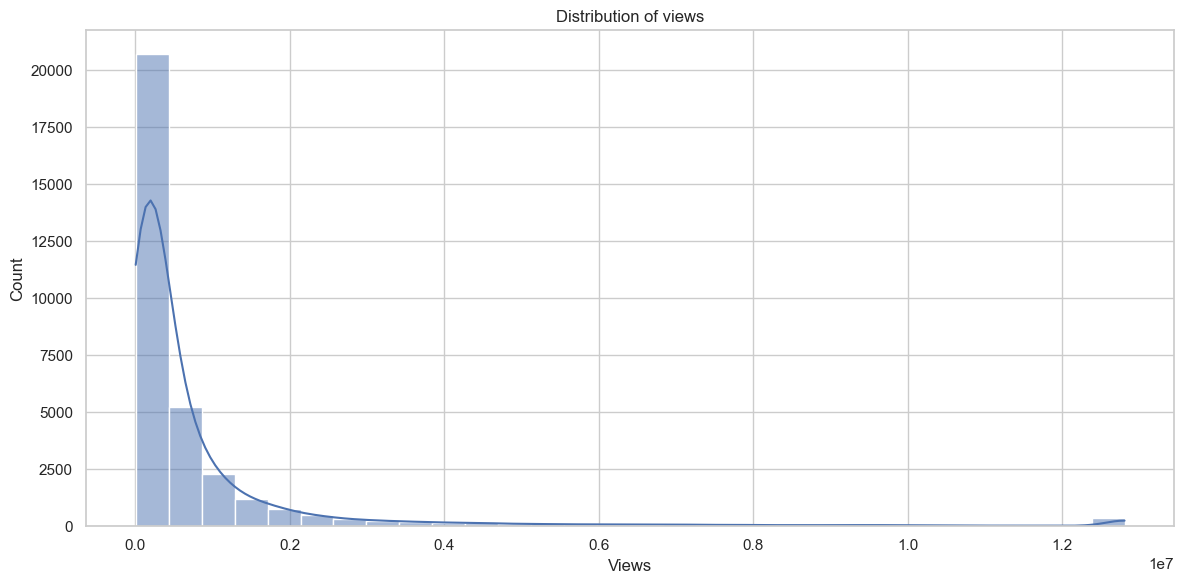

In [93]:
views_summary = df['views'].describe()
print(views_summary)

plt.figure()
sns.histplot(df['views'],bins=30,kde=True)
plt.title("Distribution of views")
plt.xlabel("Views")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/views_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [94]:
from IPython.display import display, Markdown
q1 = df["views"].quantile(0.25)
median = df["views"].quantile(0.50)
q3 = df["views"].quantile(0.75)

display(Markdown(f"**50% of trending videos have between {q1:,.0f} and {q3:,.0f} views, with a median of {median:,.0f}.**"))

**50% of trending videos have between 112,719 and 732,022 views, with a median of 275,027.**

## 7.2 Distribution of Likes

We analyze `likes` to understand how strongly trending videos are positively received.

A histogram is suitable because `likes` is a numeric continuous variable, and we want to examine its spread, concentration, and skewness across trending videos.

count    33,089.00
mean     22,465.05
std      62,483.38
min           0.00
25%         787.00
50%       2,757.00
75%      12,011.00
max     423,572.20
Name: likes, dtype: float64


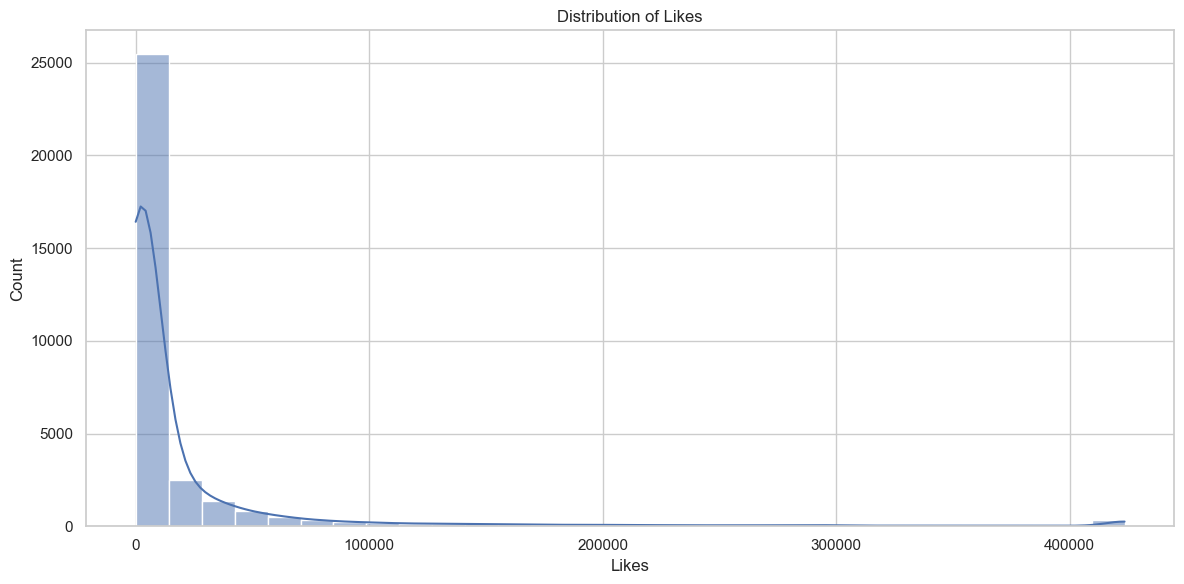

In [95]:
likes_summary = df["likes"].describe()
print(likes_summary)

plt.figure()
sns.histplot(df["likes"], bins=30, kde=True)
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/likes_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [96]:
likes_median = df['likes'].median()
likes_q3 = df['likes'].quantile(0.75)
display(Markdown(f"- **75% of trending videos have {likes_q3:,.0f} likes or fewer, while the median is {likes_median:,.0f}.**"))

- **75% of trending videos have 12,011 likes or fewer, while the median is 2,757.**

## 7.3 Distribution of Comment Count

We analyze `comment_count` to understand how much audience discussion trending videos generate.

A histogram is a good choice because `comment_count` is a numeric variable, and we want to see how comment activity is distributed across videos.
This helps us check whether most trending videos receive similar discussion levels or whether a smaller group gets much higher comment activity.

In [97]:
df["comment_count"].describe()

count   33,089.00
mean     2,002.97
std      5,839.20
min          0.00
25%         72.00
50%        298.00
75%      1,169.00
max     41,123.16
Name: comment_count, dtype: float64

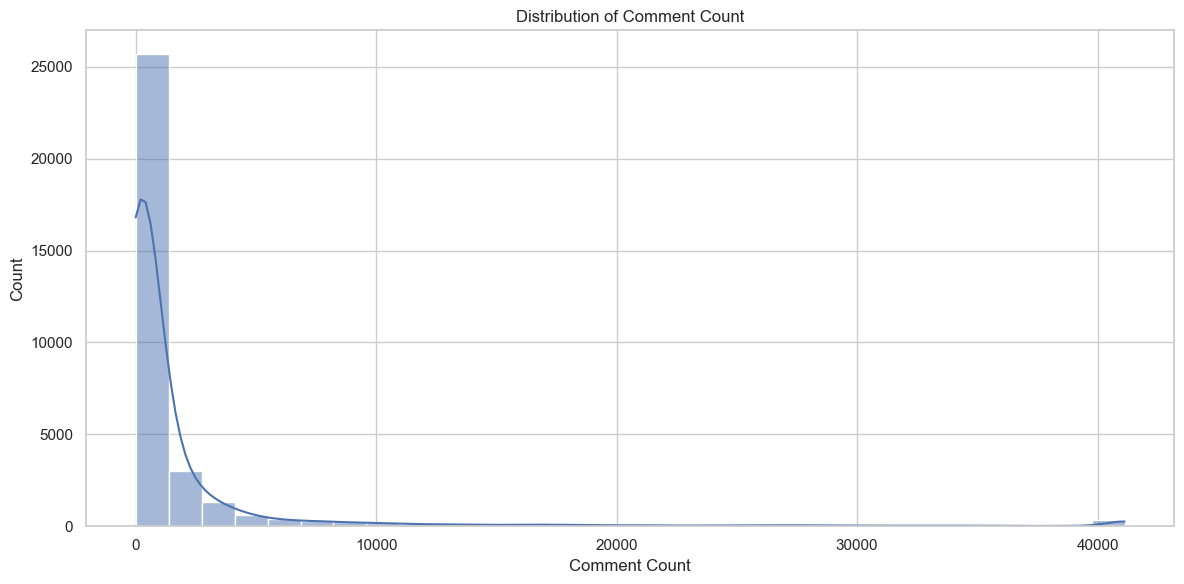

In [98]:
plt.figure()
sns.histplot(df["comment_count"], bins=30, kde=True)
plt.title("Distribution of Comment Count")
plt.xlabel("Comment Count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/comment_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
comment_median = df["comment_count"].median()
comment_q3 = df["comment_count"].quantile(0.75)
comment_a2 = df['comment_count'].quantile(0.25)
print(f"{comment_a2:,.0f}") # 25 %
display(Markdown(f"- **75% of trending videos receive {comment_q3:,.0f} comments or fewer, while the median is {comment_median:,.0f}.**"))
display(Markdown(f"- **Most videos are in low comment range only few video have high comments.**"))

72


- **75% of trending videos receive 1,169 comments or fewer, while the median is 298.**

- **Most videos are in low comment range only few video have high comments.**

## 7.4 Distribution of Days to Trend

We analyze `days_to_trend` to understand how quickly videos reach the trending list after being published.
This helps to  identify whether fast-trending behavior is common or rare.

In [100]:
days_summary = df["days_to_trend"].describe()
print(days_summary)


count   33,089.00
mean         2.11
std          2.16
min          0.00
25%          1.00
50%          2.00
75%          3.00
max        221.00
Name: days_to_trend, dtype: float64


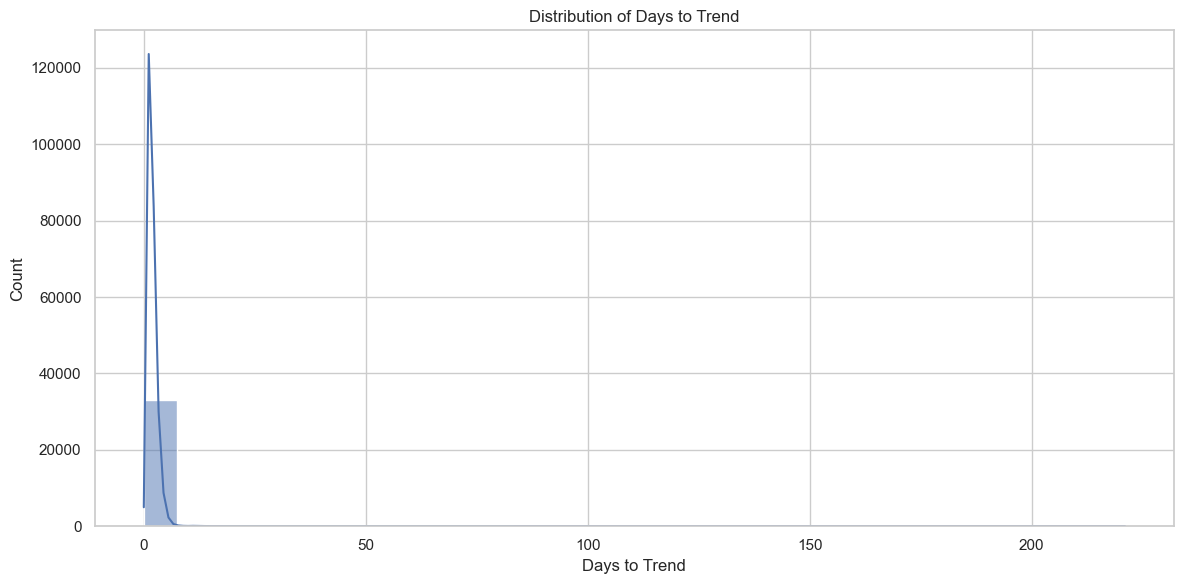

In [101]:
plt.figure()
sns.histplot(df["days_to_trend"].dropna(), bins=30, kde=True)
plt.title("Distribution of Days to Trend")
plt.xlabel("Days to Trend")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/days_to_trend_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

* Mostly videos are trend on same day  
* Median time is 2 days 

In [102]:
days_median = df["days_to_trend"].median()
days_q3 = df["days_to_trend"].quantile(0.75)

from IPython.display import display, Markdown
display(Markdown(f"- **75% of trending videos reach the trending list within {days_q3:.0f} days, while the median time is {days_median:.0f} days.**"))

- **75% of trending videos reach the trending list within 3 days, while the median time is 2 days.**

In [103]:
df["publish_weekday"].value_counts()
# reorder index 

publish_weekday
Friday       5573
Saturday     5196
Thursday     4986
Tuesday      4619
Monday       4607
Wednesday    4550
Sunday       3558
Name: count, dtype: int64

## 7.5 Distribution of Publish Weekday


In [104]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df["publish_weekday"].value_counts().reindex(weekday_order)
print(weekday_counts)

publish_weekday
Monday       4607
Tuesday      4619
Wednesday    4550
Thursday     4986
Friday       5573
Saturday     5196
Sunday       3558
Name: count, dtype: int64


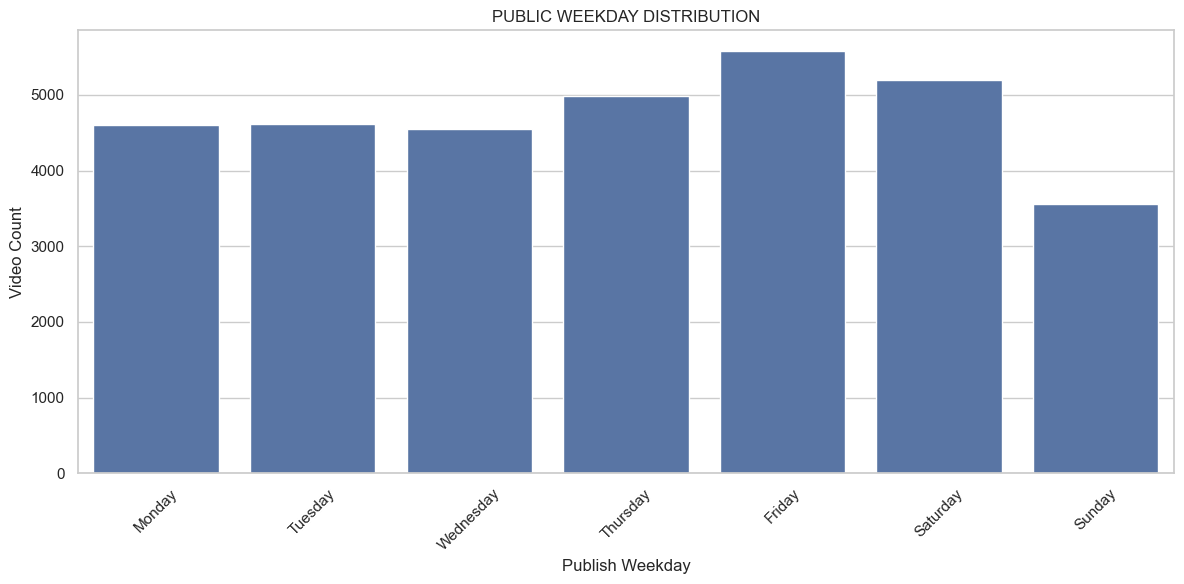

In [105]:
sns.countplot(data=df,x='publish_weekday',order=weekday_order)
plt.title("PUBLIC WEEKDAY DISTRIBUTION")
plt.xlabel("Publish Weekday",fontweight=7)
plt.ylabel("Video Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/publish_weekday_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

* Thursday to Friday spike 

In [106]:
weekday_pct = df['publish_weekday'].value_counts(normalize=True).reindex(weekday_order).mul(100).round(2)
top_day = weekday_counts.idxmax()
top_pct = weekday_pct[top_day]
print(top_day)
display(Markdown(f"- **{top_day} accounts for {top_pct:.2f}% of published trending videos, the highest share among all weekdays.**"))


Friday


- **Friday accounts for 16.84% of published trending videos, the highest share among all weekdays.**

## 7.6 Distribution of Trend Speed Band

We analyze `trend_speed_band` to understand how quickly trending videos reached the trending list.

A count plot is appropriate because `trend_speed_band` is a categorical feature with fixed groups.
This helps compare how many videos trend on the same day, within 1 to 3 days, within 4 to 7 days, or after more than 7 days.

trend_speed_band
Same Day              441
1 to 3 Days         28515
4 to 7 Days          4069
More than 7 Days       64
Name: count, dtype: int64


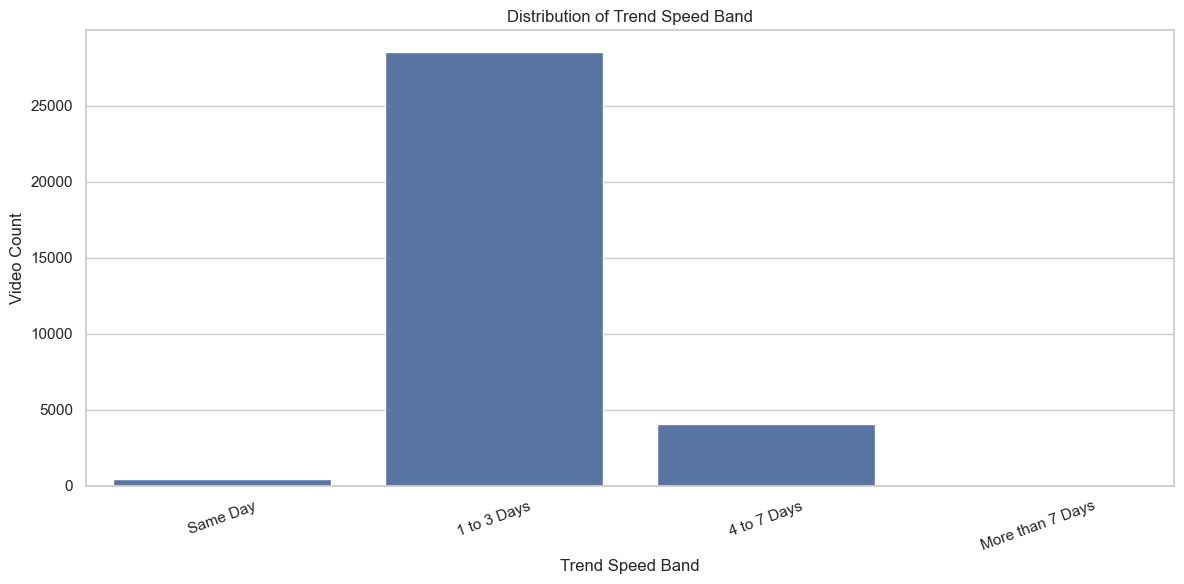

In [107]:
band_order = ["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"]
band_counts = df["trend_speed_band"].value_counts().reindex(band_order)

print(band_counts)

plt.figure()
sns.countplot(data=df, x="trend_speed_band", order=band_order)
plt.title("Distribution of Trend Speed Band")
plt.xlabel("Trend Speed Band")
plt.ylabel("Video Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/07_06_trend_speed_band_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [108]:
band_pct = df["trend_speed_band"].value_counts(normalize=True).reindex(band_order).mul(100).round(2)
top_band = band_counts.idxmax()
top_band_pct = band_pct[top_band]

display(Markdown(f"- **{top_band} is the most common trend speed band, covering {top_band_pct:.2f}% of trending videos.**"))

- **1 to 3 Days is the most common trend speed band, covering 86.18% of trending videos.**

## 7.7 Distribution of Comments Status

We analyze `comments_status` to understand how common it is for trending videos to have comments enabled or disabled.

A count plot is appropriate because `comments_status` is a categorical variable with two groups.
This helps us compare whether most trending videos allow audience discussion or restrict it.

In [109]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,has_description,publish_date,days_to_trend,publish_hour,publish_weekday,tag_use_level,trend_speed_band,views_quartile,title_length,description_length,tag_count,like_rate,comment_rate
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmish Verma | Releasing on 17 November,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry mann cute munda""|""sharry mann latest song""|""sharry mann punjabi song 2017...","1,096,327.00","33,966.00",798.00,882.00,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cute Munda Teaser . The music of new punjabi song is given by Gift Ruler...,1,2017-11-12,2,12,Sunday,High Tag use,1 to 3 Days,Q4,81,920,15,0.03,0.00
1,zUZ1z7FwLc8,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे",HJ NEWS,25,2017-11-13 05:43:56+00:00,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर दंग रह जायेंगे""|""latest news""|""today news""|""news""|""breaking news""|""curr...","590,101.00",735.00,904.00,0.00,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दंग रह जायेंगे \n\nWatch this video :- https://youtu.be/zUZ1z7FwLc8\n\nH...",1,2017-11-13,1,5,Monday,High Tag use,1 to 3 Days,Q3,58,2232,19,0.00,0.00
2,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Reception | TFPC,TFPC,24,2017-11-12 15:48:08+00:00,"Stylish Star Allu Arjun @ ChaySam Wedding Reception|""Stylish Star Allu Arjun""|""ChaySam Wedding Reception""|""nagachait...","473,988.00","2,011.00",243.00,149.00,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,"Watch Stylish Star Allu Arjun @ ChaySam Wedding Reception \n\n☛ For latest news https://www.tfpc.in, https://goo.gl...",1,2017-11-12,2,15,Sunday,Medium Tag use,1 to 3 Days,Q3,58,482,14,0.00,0.00
3,N1vE8iiEg64,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Movies""|""Harija""|""Short""|""Film""|""Eruma Sani""|""Eruma Saani Videos""|""Eruma ...","1,242,680.00","70,353.00","1,624.00","2,684.00",https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between people who speak in English and Tamil in a very funny way.\nSubscribe to...,1,2017-11-12,2,7,Sunday,High Tag use,1 to 3 Days,Q4,30,263,20,0.06,0.00
4,kJzGH0PVQHQ,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks,Filmylooks,24,2017-11-13 01:14:16+00:00,"Filmylooks|""latest news""|""telugu movies""|""telugu news""|""Tollywood news""|""why Samantha became EMOTIONAL @ Samantha na...","464,015.00",492.00,293.00,66.00,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga chaithanya marriage Reception | Filmylooks #samantha #Nagachaithanya \...,1,2017-11-13,1,1,Monday,Medium Tag use,1 to 3 Days,Q3,88,753,11,0.00,0.00


In [110]:
df["comments_status"] = df["comments_disabled"].map({True: "Disabled", False: "Enabled"})
print(df[["comments_disabled", "comments_status"]].head())
print(df["comments_status"].value_counts())

   comments_disabled comments_status
0              False         Enabled
1               True        Disabled
2              False         Enabled
3              False         Enabled
4              False         Enabled
comments_status
Enabled     31984
Disabled     1105
Name: count, dtype: int64


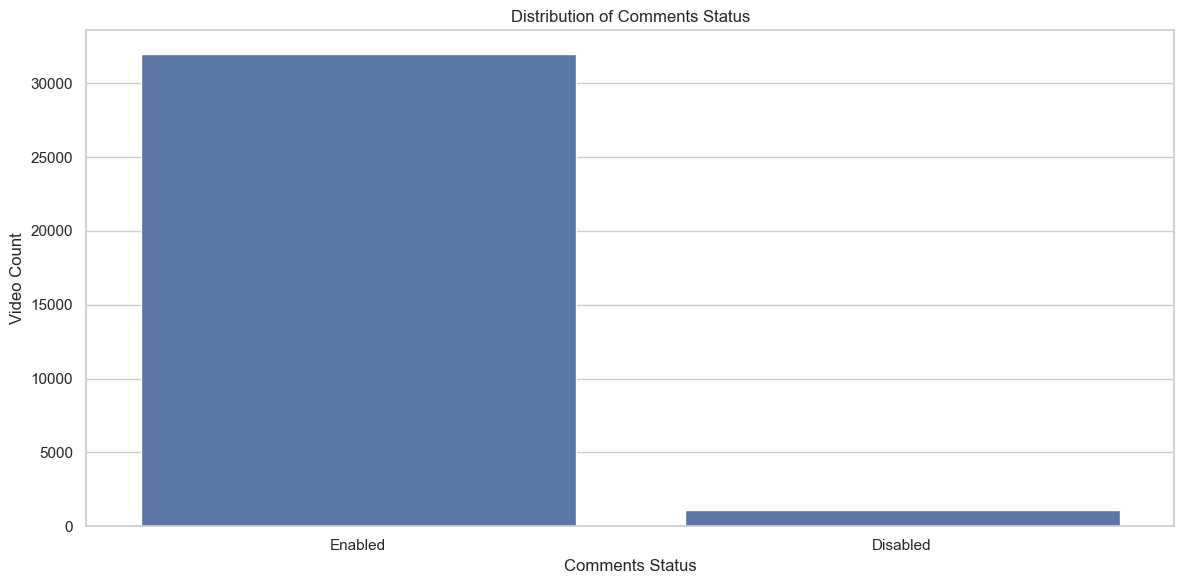

In [111]:
plt.figure()
sns.countplot(data=df, x="comments_status", order=["Enabled", "Disabled"])
plt.title("Distribution of Comments Status")
plt.xlabel("Comments Status")
plt.ylabel("Video Count")
plt.tight_layout()
plt.savefig("../images/comments_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [112]:
comments_status_pct = df["comments_status"].value_counts(normalize=True).mul(100).round(2)
enabled_pct = comments_status_pct["Enabled"]

display(Markdown(f"- **{enabled_pct:.2f}% of trending videos have comments enabled.**"))


- **96.66% of trending videos have comments enabled.**

## 7.8 Distribution of Ratings Status

We analyze `ratings_status` to understand how common it is for trending videos to have ratings enabled or disabled.

A count plot is appropriate because `ratings_status` is a categorical variable with two groups.
This helps us compare whether most trending videos allow likes/dislikes or restrict rating activity.


In [113]:
df["ratings_status"] = df["ratings_disabled"].map({True: "Disabled", False: "Enabled"})
ratings_status_counts = df["ratings_status"].value_counts()
ratings_status_counts

ratings_status
Enabled     32378
Disabled      711
Name: count, dtype: int64

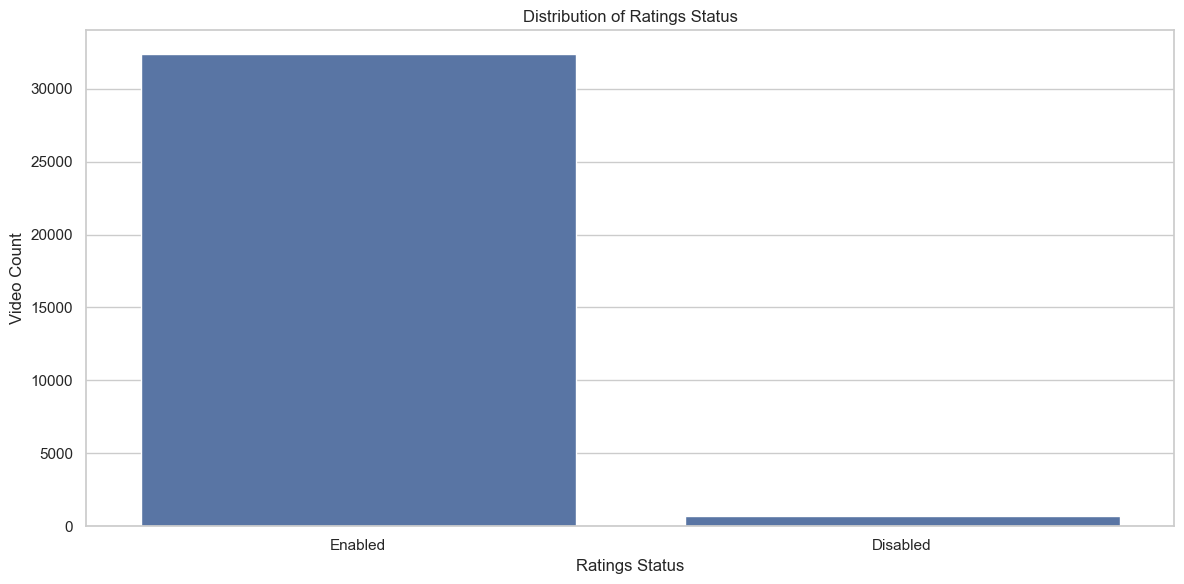

In [114]:
plt.figure()
sns.countplot(data=df, x="ratings_status", order=["Enabled", "Disabled"])
plt.title("Distribution of Ratings Status")
plt.xlabel("Ratings Status")
plt.ylabel("Video Count")
plt.tight_layout()
plt.savefig("../images/ratings_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [115]:
ratings_status_pct = df["ratings_status"].value_counts(normalize=True).mul(100).round(2)
enabled_pct = ratings_status_pct["Enabled"]

display(Markdown(f"- **{enabled_pct:.2f}% of trending videos have ratings enabled.**"))

- **97.85% of trending videos have ratings enabled.**

## 7.9 Distribution of Tag Use Level

We analyze `tag_use_level` to understand how heavily trending videos use tags.

A count plot is appropriate because `tag_use_level` is a categorical variable with grouped labels.
This helps compare whether trending videos more often use no tags, a few tags, a medium number of tags, or many tags.

In [116]:
tag_order = ["No Tags", "Low Tag Use", "Medium Tag Use", "High Tag Use"]
tag_counts = df["tag_use_level"].value_counts()
print(tag_counts)

tag_use_level
High Tag use      21120
Medium Tag use     9252
Low Tag use        2717
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\1633526913.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='tag_use_level',palette='Set2')


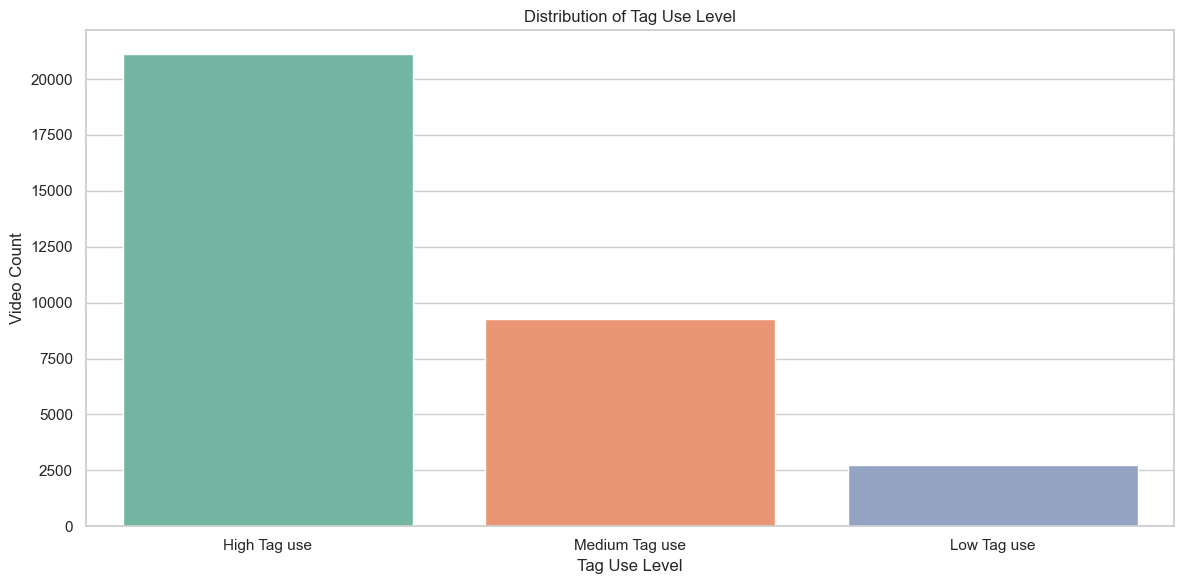

In [117]:
sns.countplot(data=df,x='tag_use_level',palette='Set2')
plt.title("Distribution of Tag Use Level")
plt.xlabel("Tag Use Level")
plt.ylabel("Video Count")
plt.xticks()
plt.tight_layout()
plt.savefig("../images/tag_use_level_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [118]:

tag_pct = df["tag_use_level"].value_counts(normalize=True).mul(100).round(2)
top_tag_group = tag_counts.idxmax()
top_tag_pct = tag_pct[top_tag_group]

display(Markdown(f"- **{top_tag_group} is the most common tag pattern, covering {top_tag_pct:.2f}% of trending videos.**"))

- **High Tag use is the most common tag pattern, covering 63.83% of trending videos.**

## 7.10 Distribution of Like Rate

We analyze `like_rate` to understand how efficiently trending videos convert views into likes.

A histogram is appropriate because `like_rate` is a numeric continuous variable. 
This helps us see the typical engagement ratio for a trending video, showing whether most videos get similar like ratios or if a few are exceptionally highly liked.

count   33,089.00
mean         0.02
std          0.03
min          0.00
25%          0.00
50%          0.01
75%          0.03
max          0.38
Name: like_rate, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\3655054275.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["like_rate"], bins=40, kde=True,palette='Set2')


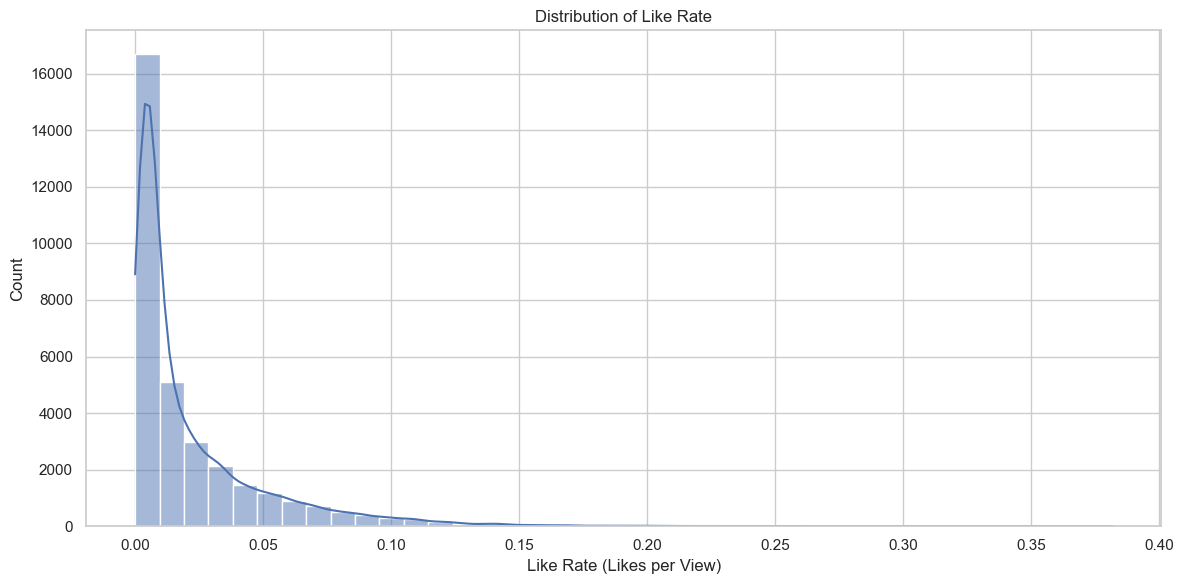

In [119]:
like_rate_summary = df["like_rate"].describe()

print(like_rate_summary)
sns.histplot(df["like_rate"], bins=40, kde=True,palette='Set2')
plt.title("Distribution of Like Rate")
plt.xlabel("Like Rate (Likes per View)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../images/like_rate_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
from IPython.display import display, Markdown

like_rate_median = df["like_rate"].median()
like_rate_q3 = df["like_rate"].quantile(0.75)

display(Markdown(f"- **The median like rate is {like_rate_median:.4f}, meaning a typical trending video gets about {(like_rate_median * 100):.2f} likes per 100 views.**"))

- **The median like rate is 0.0094, meaning a typical trending video gets about 0.94 likes per 100 views.**

# 8. BIVARIATE ANALYSIS

In this section, we compare two variables at a time to find relationships.
Each comparison includes a chart and 

comments_status
Disabled   425,048.00
Enabled    898,694.00
Name: views, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\1279533090.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="comments_status", y="views", estimator="mean", ci=None, order=["Enabled", "Disabled"])


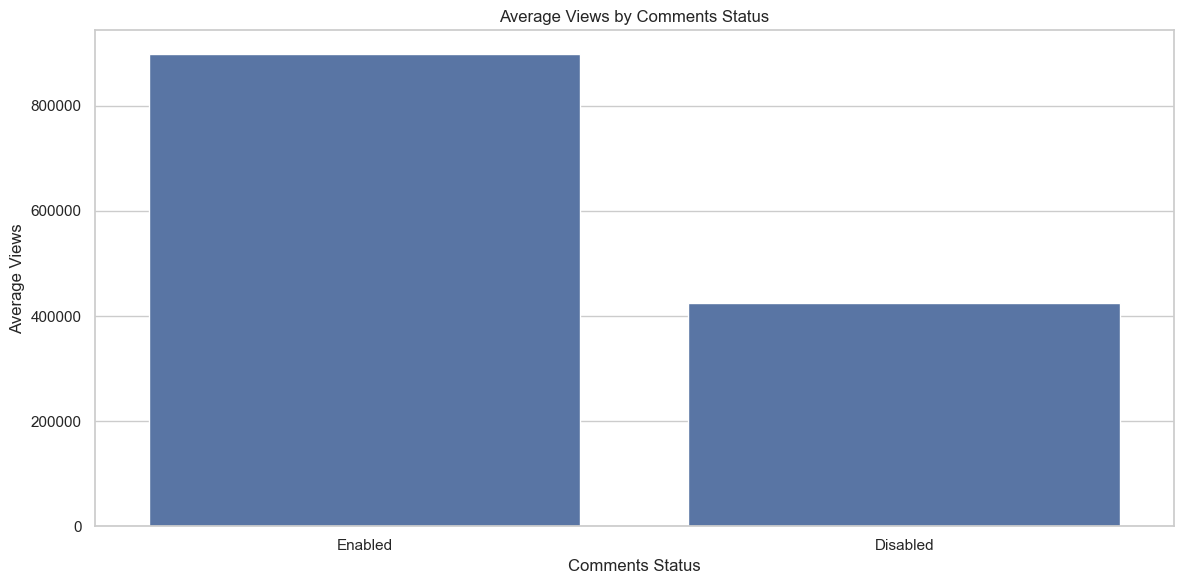

In [121]:
# 8.1 Views by Comments Status
views_by_comments = df.groupby("comments_status")["views"].mean().round(0)
print(views_by_comments)

plt.figure()
sns.barplot(data=df, x="comments_status", y="views", estimator="mean", ci=None, order=["Enabled", "Disabled"])
plt.title("Average Views by Comments Status")
plt.xlabel("Comments Status")
plt.ylabel("Average Views")
plt.tight_layout()
plt.savefig("../images/_views_by_comments_status.png", dpi=300, bbox_inches="tight")
plt.show()

In [122]:

enabled_views = views_by_comments["Enabled"]
disabled_views = views_by_comments["Disabled"]
diff_pct = ((enabled_views - disabled_views) / disabled_views * 100).round(2)

display(Markdown(f"- **Videos with comments enabled receive {diff_pct}% more average views than videos with comments disabled.**"))

- **Videos with comments enabled receive 111.43% more average views than videos with comments disabled.**

trend_speed_band
Same Day             197,378.00
1 to 3 Days          633,206.00
4 to 7 Days        2,654,410.00
More than 7 Days   4,215,678.00
Name: views, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\286844014.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="trend_speed_band", y="views", estimator="mean", ci=None,


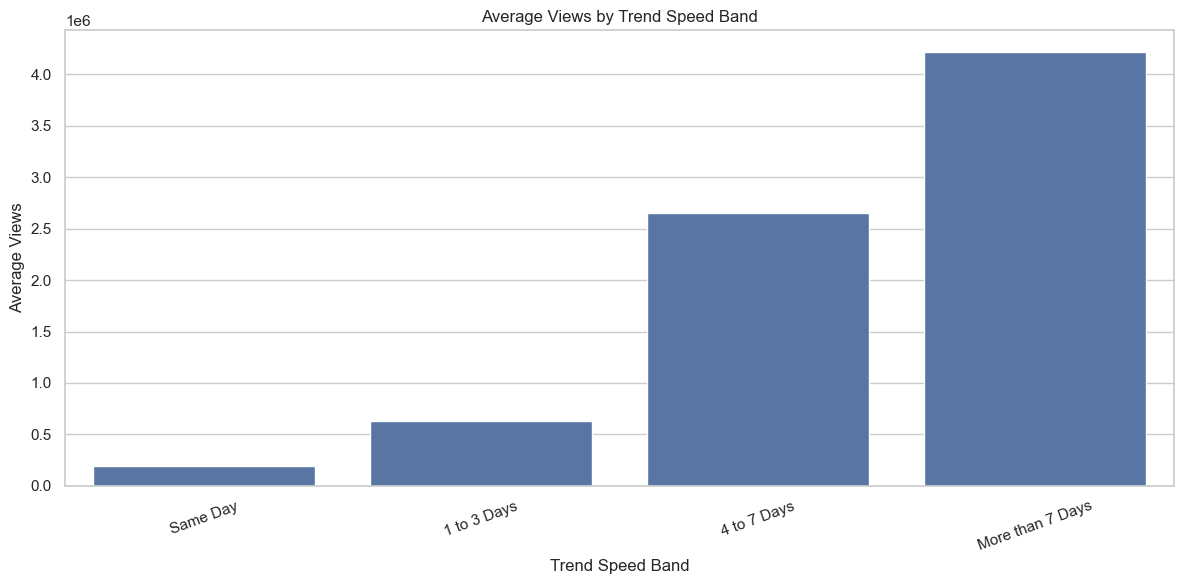

In [123]:
# 8.2 Views by Trend Speed Band
views_by_speed = df.groupby("trend_speed_band", observed=False)["views"].mean().reindex(
    ["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"]
).round(0)

print(views_by_speed)

plt.figure()
sns.barplot(data=df, x="trend_speed_band", y="views", estimator="mean", ci=None,
            order=["Same Day", "1 to 3 Days", "4 to 7 Days", "More than 7 Days"])
plt.title("Average Views by Trend Speed Band")
plt.xlabel("Trend Speed Band")
plt.ylabel("Average Views")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/views_by_trend_speed.png", dpi=300, bbox_inches="tight")
plt.show()

In [124]:
top_speed = views_by_speed.idxmax()
top_speed_views = views_by_speed.max()

display(Markdown(f"- **Videos in the '{top_speed}' band have the highest average views at {top_speed_views:,.0f}.**"))

- **Videos in the 'More than 7 Days' band have the highest average views at 4,215,678.**

In [125]:
top_speed = views_by_speed.idxmax()
top_speed_views = views_by_speed.max()

display(Markdown(f"- **Videos in the '{top_speed}' band have the highest average views at {top_speed_views:,.0f}.**"))

- **Videos in the 'More than 7 Days' band have the highest average views at 4,215,678.**

In [127]:
"""top_tag = views_by_tag.idxmax()
top_tag_views = views_by_tag.max()
low_tag_views = views_by_tag["No Tags"]

display(Markdown(f"- **'{top_tag}' videos average {top_tag_views:,.0f} views, while 'No Tags' videos average {low_tag_views:,.0f} views.**"))"""

'top_tag = views_by_tag.idxmax()\ntop_tag_views = views_by_tag.max()\nlow_tag_views = views_by_tag["No Tags"]\n\ndisplay(Markdown(f"- **\'{top_tag}\' videos average {top_tag_views:,.0f} views, while \'No Tags\' videos average {low_tag_views:,.0f} views.**"))'

views_quartile
Q1    1,312.00
Q2    3,389.00
Q3    9,317.00
Q4   75,845.00
Name: likes, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\2377121296.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="views_quartile", y="likes", estimator="mean", ci=None,


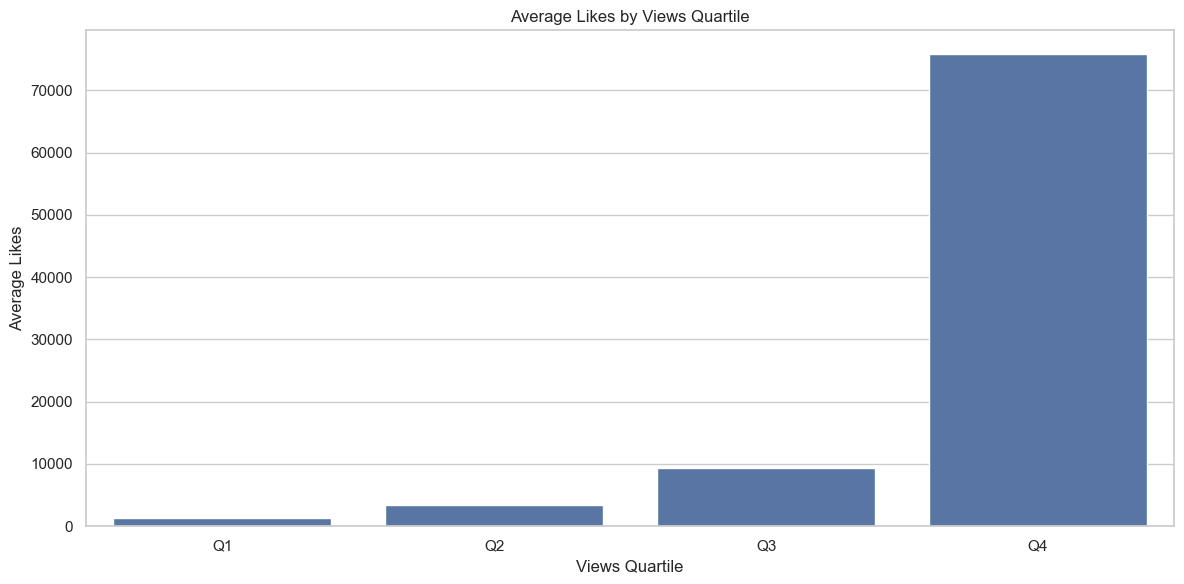

In [128]:
# 8.4 Likes by Views Quartile
likes_by_quartile = df.groupby("views_quartile", observed=False)["likes"].mean().round(0)

print(likes_by_quartile)

plt.figure()
sns.barplot(data=df, x="views_quartile", y="likes", estimator="mean", ci=None,
            order=["Q1", "Q2", "Q3", "Q4"])
plt.title("Average Likes by Views Quartile")
plt.xlabel("Views Quartile")
plt.ylabel("Average Likes")
plt.tight_layout()
plt.savefig("../images/08_04_likes_by_views_quartile.png", dpi=300, bbox_inches="tight")
plt.show()

In [129]:
q4_likes = likes_by_quartile["Q4"]
q1_likes = likes_by_quartile["Q1"]
likes_diff = ((q4_likes - q1_likes) / q1_likes * 100).round(2)

display(Markdown(f"- **Q4 (highest views) videos receive {likes_diff}% more likes on average compared to Q1 (lowest views) videos.**"))

- **Q4 (highest views) videos receive 5680.87% more likes on average compared to Q1 (lowest views) videos.**

publish_weekday
Monday      1,072,669.00
Tuesday       956,074.00
Wednesday   1,010,271.00
Thursday      914,707.00
Friday        806,822.00
Saturday      701,203.00
Sunday        719,023.00
Name: views, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_16460\1337808350.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="publish_weekday", y="views", estimator="mean", ci=None, order=weekday_order)


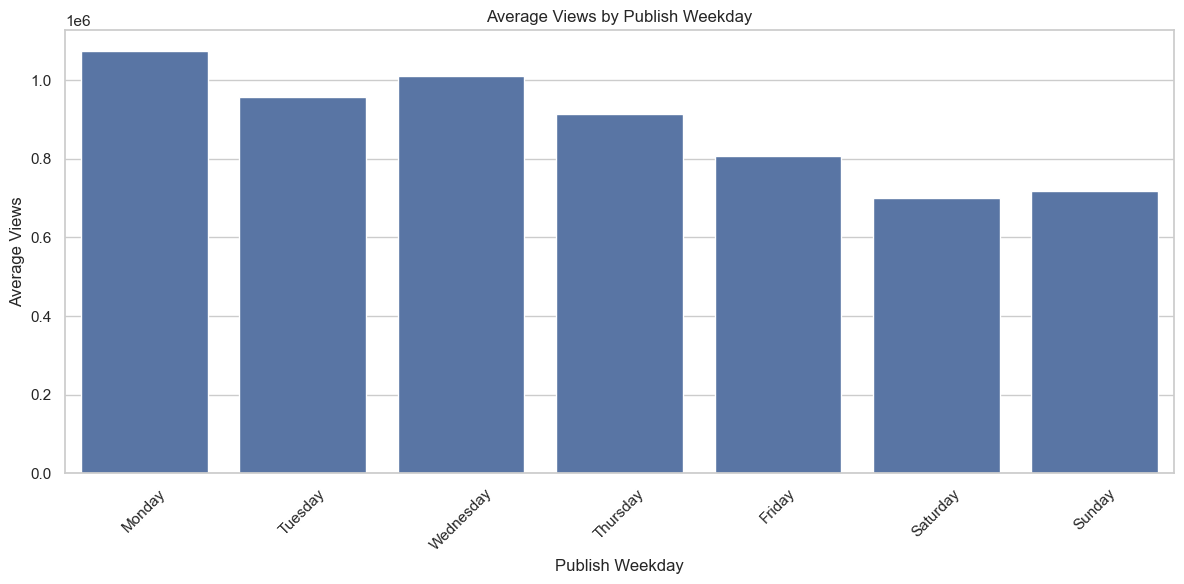

In [130]:
# 8.5 Views by Publish Weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
views_by_weekday = df.groupby("publish_weekday")["views"].mean().reindex(weekday_order).round(0)

print(views_by_weekday)

plt.figure()
sns.barplot(data=df, x="publish_weekday", y="views", estimator="mean", ci=None, order=weekday_order)
plt.title("Average Views by Publish Weekday")
plt.xlabel("Publish Weekday")
plt.ylabel("Average Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/08_05_views_by_weekday.png", dpi=300, bbox_inches="tight")
plt.show()

In [131]:
best_day = views_by_weekday.idxmax()
best_day_views = views_by_weekday.max()
worst_day = views_by_weekday.idxmin()
worst_day_views = views_by_weekday.min()

display(Markdown(f"- **{best_day} has the highest average views ({best_day_views:,.0f}) while {worst_day} has the lowest ({worst_day_views:,.0f}).**"))

- **Monday has the highest average views (1,072,669) while Saturday has the lowest (701,203).**

# 9. MULTIVARIATE ANALYSIS
.
We use correlation heatmaps, pivot tables, and pairplots to capture multi-dimensional patterns.

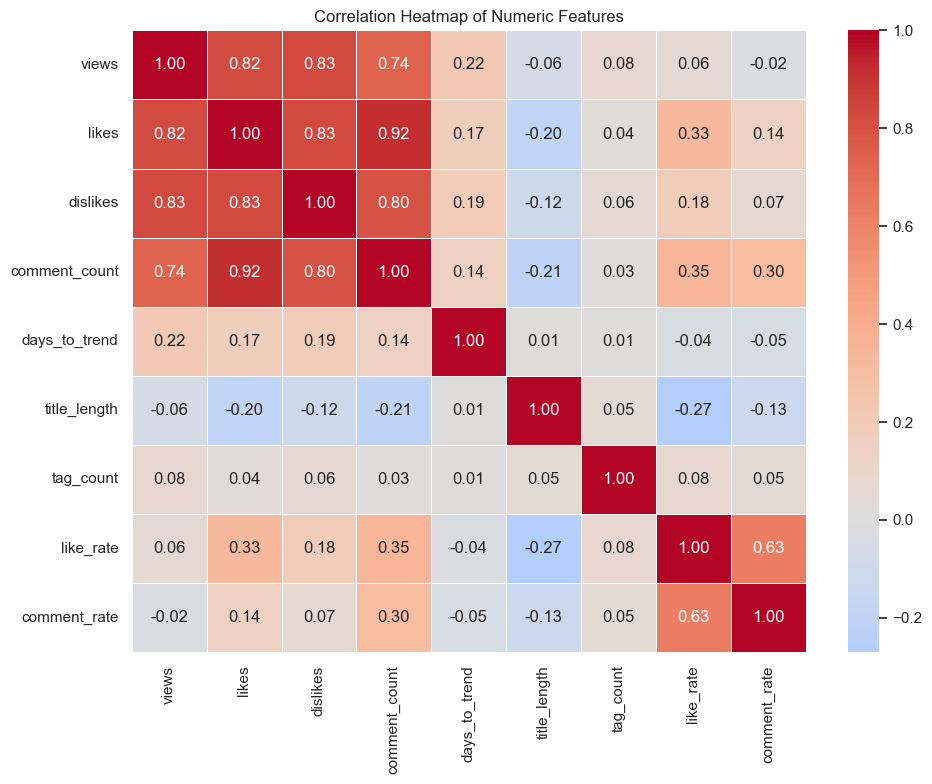

In [132]:
# 9.1 Correlation Heatmap
numeric_cols = ["views", "likes", "dislikes", "comment_count", "days_to_trend",
                "title_length", "tag_count", "like_rate", "comment_rate"]

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("../images/09_01_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [133]:
top_corr = (
    corr_matrix.unstack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
top_corr = top_corr[top_corr["Feature_1"] != top_corr["Feature_2"]]
top_corr = top_corr.drop_duplicates(subset=["Correlation"])
top_corr = top_corr.sort_values("Correlation", ascending=False).head(5)

display(Markdown("**Top 5 strongest correlations:**"))
for _, row in top_corr.iterrows():
    display(Markdown(f"- **{row['Feature_1']}** & **{row['Feature_2']}**: **{row['Correlation']}**"))

**Top 5 strongest correlations:**

- **likes** & **comment_count**: **0.92**

- **views** & **dislikes**: **0.83**

- **views** & **likes**: **0.82**

- **dislikes** & **comment_count**: **0.8**

- **views** & **comment_count**: **0.74**

trend_speed_band   Same Day  1 to 3 Days  4 to 7 Days  More than 7 Days
tag_use_level                                                          
High Tag use     211,739.86   712,411.00 2,835,931.71      4,428,541.93
Low Tag use      193,497.86   494,699.28 1,803,976.10        288,844.38
Medium Tag use   166,104.36   497,857.00 2,372,296.96      6,053,064.73


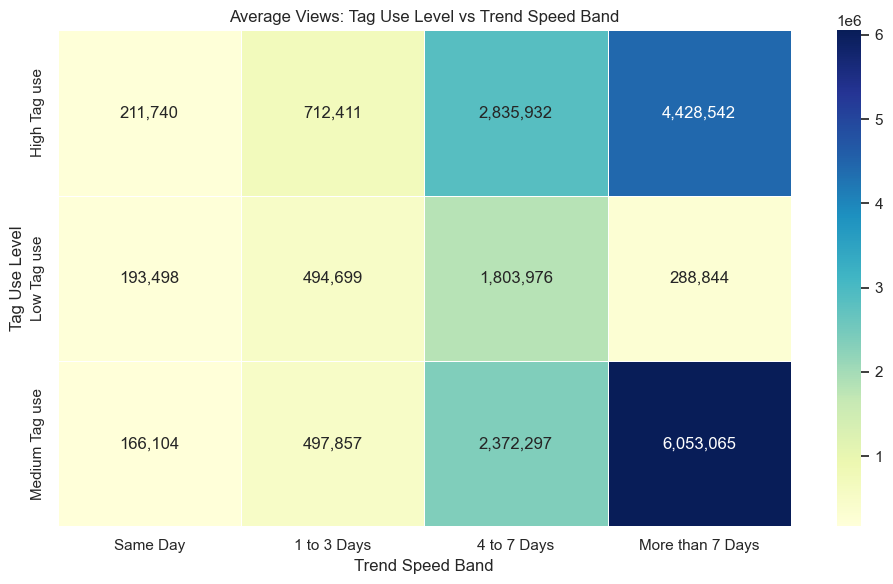

In [ ]:
# 9.2 Pivot Table: Avg Views by Tag Use Level and Trend Speed Band
pivot = df.pivot_table(
    values="views",
    index="tag_use_level",
    columns="trend_speed_band",
    aggfunc="mean",
    observed=False
)
print(pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Average Views: Tag Use Level vs Trend Speed Band")
plt.xlabel("Trend Speed Band")
plt.ylabel("Tag Use Level")
plt.tight_layout()
plt.savefig("../images/09_02_pivot_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [136]:
max_cell = pivot.stack().idxmax()
max_value = pivot.stack().max()

display(Markdown(f"- **Highest average views ({max_value:,.0f}) are found in '{max_cell[0]}' videos that trended in '{max_cell[1]}'.**"))

- **Highest average views (6,053,065) are found in 'Medium Tag use' videos that trended in 'More than 7 Days'.**

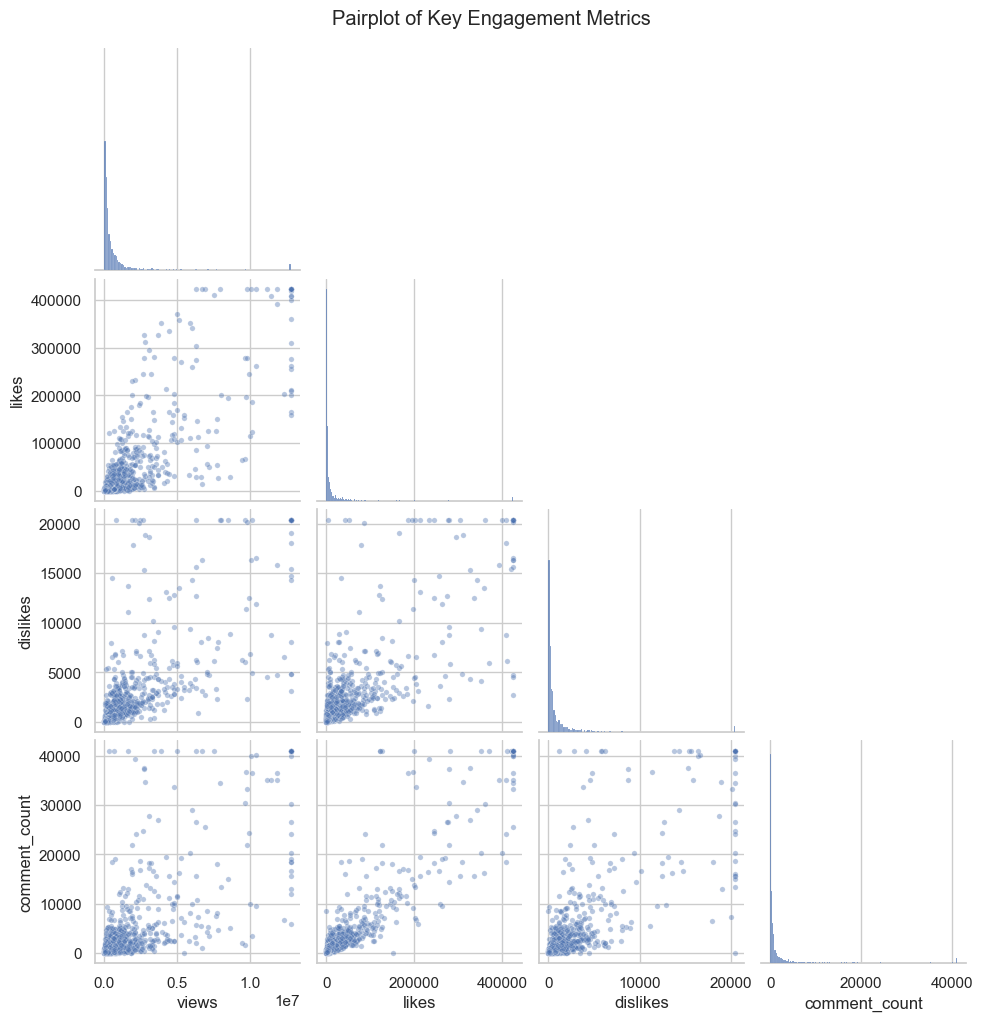

In [137]:
# 9.3 Pairplot of Key Engagement Metrics
pair_cols = ["views", "likes", "dislikes", "comment_count"]

sample_df = df[pair_cols].sample(2000, random_state=42)

sns.pairplot(sample_df, corner=True, plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairplot of Key Engagement Metrics", y=1.02)
plt.savefig("../images/09_03_pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [138]:
display(Markdown("- **Views, likes, dislikes, and comment count show strong positive linear relationships, confirming that higher-view videos consistently attract more engagement across all metrics.**"))

- **Views, likes, dislikes, and comment count show strong positive linear relationships, confirming that higher-view videos consistently attract more engagement across all metrics.**

# 10. KEY INSIGHTS

- **4,263 duplicate rows were removed, reducing the working dataset to 33,089 cleaned records.**
- **Only `description` had missing values (561 rows), and those rows were preserved by filling a placeholder value.**
- **The median trending time is 2 days, and 75% of videos reach trending within 3 days.**
- **Trending speed is highly concentrated early, but a few videos take much longer, with a maximum of 221 days.**
- **Friday has the highest upload count with 5,573 videos (16.84%), while Sunday has the lowest with 3,558 videos (10.75%).**

- **Comment activity is uneven: the median is 298 comments, while 75% of videos receive 1,169 comments or fewer.**
- **Views are highly imbalanced across performance groups: Q4 videos average 2.83M views versus 63.49K in Q1, a gap of about 44.6x.**
- **High Tag Use is the most common tag pattern among trending videos, while Medium Tag Use is less common.**
- **97.85% of trending videos have ratings enabled, making open rating access the standard pattern.**
- **Views, likes, dislikes, and comment counts move positively together, showing that higher reach usually brings higher engagement.**

# 11. RECOMMENDATIONS

- **Prioritize the first 48 to 72 hours after upload, because most trending videos appear within 3 days.**
- **Test Thursday, Friday, and Saturday uploads first, since these days show stronger trending upload activity.**
- **Keep ratings enabled by default, because this is the dominant pattern among trending videos.**
- **Use complete metadata on every upload: a clear title, a filled description, and relevant tags.**
- **Use richer tag coverage where relevant, but avoid adding random or misleading keywords.**
- **Track `like_rate` and `comment_rate` along with views, because raw views alone do not show engagement quality.**
- **Encourage early discussion with pinned comments, questions, or call-to-actions to improve interaction.**
- **Review very late-trending videos separately, because they may follow a different discovery pattern than fast-trending videos.**
- **Set channel targets using view quartiles, so performance is judged against realistic bands rather than rare viral outliers.**
